Pergunta de pesquisa

Em que medida os municípios da 2ª Regional de Saúde dependem de Curitiba para internações obstétricas e como as características das vias de acesso podem representar potenciais vulnerabilidades territoriais para esse fluxo assistencial?

Objetivo

Analisar a rede de dependência dos municípios da 2ª Regional de Saúde em relação a Curitiba para internações obstétricas e examinar as rotas rodoviárias utilizadas nesse fluxo assistencial.

Métodos

O período de análise considerado neste estudo corresponde ao mês de novembro de 2025. A análise dos fluxos assistenciais permite explorar a relação entre dependência hospitalar e acessibilidade territorial.

Inicialmente, foram utilizados dados do SIH/SUS para identificar as internações obstétricas ocorridas no período analisado. Para isso, foram selecionados os registros cujo diagnóstico principal pertence ao capítulo “O” da Classificação Internacional de Doenças (CID-10), correspondente às condições relacionadas à gravidez, parto e puerpério.

A partir desses dados, foram analisados os fluxos de internação considerando o município de residência da paciente e o município onde ocorreu a internação. Com base nessas informações foram construídos indicadores que permitiram identificar o grau de dependência dos municípios da 2ª Regional de Saúde em relação aos serviços hospitalares localizados em Curitiba.

Entre os indicadores calculados estão:

-número total de internações obstétricas de residentes em cada município;

-número de internações realizadas fora do município de residência;

-proporção de exportação de internações;

-número de internações realizadas em Curitiba;

-proporção de dependência em relação à capital.

Com base nesses indicadores, foram identificados os municípios com maior dependência hospitalar de Curitiba. Para uma análise mais detalhada da acessibilidade territorial, foram selecionados os quatro municípios com maior proporção de internações obstétricas realizadas na capital. Esses municípios foram:

-Campo Largo
-Campo Magro
-Doutor Ulysses
-Rio Branco do Sul

Para esses municípios foi realizada uma análise da acessibilidade rodoviária até Curitiba. A rede viária da região foi modelada a partir de dados do OpenStreetMap, utilizando a biblioteca OSMnx em ambiente Python. A rede rodoviária foi previamente armazenada em formato GraphML, permitindo sua reutilização no processo de análise.

A partir dessa rede viária, foram identificadas as rotas rodoviárias mais curtas entre as sedes municipais dos municípios selecionados e Curitiba, utilizando algoritmos de caminho mínimo implementados na biblioteca NetworkX. Para cada rota foram calculados:

-a distância total do trajeto;

-o tempo estimado de deslocamento;

-as rodovias utilizadas ao longo do percurso.

Essas informações foram organizadas em uma tabela analítica final que combina indicadores de dependência hospitalar com métricas de acessibilidade territorial, permitindo examinar simultaneamente o grau de dependência dos municípios em relação à capital e o esforço de deslocamento necessário para acessar os serviços hospitalares.

A partir dessa integração, torna-se possível analisar como a estrutura territorial da rede viária se relaciona com os fluxos assistenciais observados entre os municípios da 2ª Regional de Saúde e Curitiba.

Limitações:
O estudo considera as rotas rodoviárias mais curtas estimadas a partir da rede viária derivada do OpenStreetMap, que representam trajetos potenciais entre os municípios e Curitiba, mas não necessariamente os percursos efetivamente realizados pelos pacientes. A análise não incorpora informações empíricas sobre condições dinâmicas da infraestrutura viária, como congestionamentos, bloqueios ou acidentes, o que constitui uma dimensão relevante para investigações futuras sobre a vulnerabilidade territorial do acesso aos serviços obstétricos.

Contribuições:
Este estudo contribui para a compreensão da organização territorial da assistência obstétrica ao integrar dados de fluxos hospitalares com análise de acessibilidade rodoviária. Ao identificar os municípios da 2ª Regional de Saúde com maior dependência de Curitiba para internações obstétricas e modelar as rotas rodoviárias utilizadas nesse deslocamento, a pesquisa oferece uma perspectiva territorial sobre a dinâmica de acesso aos serviços hospitalares. A abordagem metodológica adotada, que combina informações do Sistema de Informações Hospitalares do Sistema Único de Saúde (SIH/SUS) disponibilizadas pelo DATASUS com modelagem da rede viária baseada em dados do OpenStreetMap, permite evidenciar não apenas a dependência assistencial em relação à capital, mas também o esforço territorial necessário para acessar esses serviços. Dessa forma, o estudo amplia a compreensão sobre as relações entre organização regional da saúde e infraestrutura de mobilidade, oferecendo subsídios para futuras investigações sobre vulnerabilidade territorial e planejamento da rede de atenção obstétrica.

In [4]:
# instalar dependências
#!pip install dbfread
#!pip install geopandas
#!pip install osmnx

In [5]:
from pathlib import Path
import pandas as pd
from dbfread import DBF
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import unicodedata
import networkx as nx
import osmnx as ox
import pickle

In [6]:
# ajuste de caminhos

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    DATA_DIR = Path('/content/drive/MyDrive/Projeto Indicadores/data')
else:
    DATA_DIR = Path(r'C:\Users\Avell\Desktop\Projeto\data')

DBF_DIR_SIM = DATA_DIR / 'raw' / 'SIM'
CSV_DIR_SIH = DATA_DIR / 'raw' / 'SIH'
DIR_IBGE = DATA_DIR / 'raw' / 'IBGE'
AUX_DIR = DATA_DIR / 'auxiliary'
OUT_DIR = DATA_DIR / 'processed'
GEO_DIR = DATA_DIR / 'geo'
GRAPHML_DIR = DATA_DIR / 'graphml'
GNN_DIR = DATA_DIR / 'gnn'
OUT_DIR.mkdir(parents=True, exist_ok=True)

MUN2RS_FILE = AUX_DIR / 'municipalities_health_regions_pr.xlsx'
RS_FILE = AUX_DIR / 'health_regions_pr.xlsx'
GRAPHML_FILE = GRAPHML_DIR / 'road_network_2hr.graphml'
GNN_FILE = GNN_DIR / 'graph_2025_nov.pkl'
GNN_CSV_FILE = GNN_DIR / 'features_2025_nov.csv'

DBF_DIR_SIM, MUN2RS_FILE

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(PosixPath('/content/drive/MyDrive/Projeto Indicadores/data/raw/SIM'),
 PosixPath('/content/drive/MyDrive/Projeto Indicadores/data/auxiliary/municipalities_health_regions_pr.xlsx'))

In [7]:
sih2025 = DBF(CSV_DIR_SIH / 'RDPR2511.dbf', load=True)

df_sih2025 = pd.DataFrame(iter(sih2025))

df_sih2025

,UF_ZI,ANO_CMPT,MES_CMPT,ESPEC,CGC_HOSP,N_AIH,IDENT,CEP,MUNIC_RES,NASC,...,TPDISEC1,TPDISEC2,TPDISEC3,TPDISEC4,TPDISEC5,TPDISEC6,TPDISEC7,TPDISEC8,TPDISEC9,FONTE_ORC
0,410000,2025,11,01,08325231001400,4125500223119,1,86010420,411370,19550115,...,0,0,0,0,0,0,0,0,0,00
1,410000,2025,11,01,08325231001400,4125500223120,1,86240000,412600,19770921,...,0,0,0,0,0,0,0,0,0,00
2,410000,2025,11,01,08325231001400,4125500223130,1,87660000,411810,19501016,...,0,0,0,0,0,0,0,0,0,00
3,410000,2025,11,01,08325231001400,4125500223141,1,86350000,412390,19541018,...,0,0,0,0,0,0,0,0,0,00
4,410000,2025,11,01,08325231001400,4125500223152,1,87180000,412040,19680629,...,0,0,0,0,0,0,0,0,0,00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91781,412810,2025,11,03,06019110000181,4125104757940,1,87503020,412810,19600923,...,0,0,0,0,0,0,0,0,0,00
91782,412810,2025,11,03,06019110000181,4125104757994,1,87510652,412810,19710709,...,0,0,0,0,0,0,0,0,0,00
91783,412810,2025,11,03,06019110000181,4125104758016,1,87540000,411890,19860310,...,1,0,0,0,0,0,0,0,0,00
91784,412810,2025,11,02,05866492000116,4125104756784,1,87570000,410832,19960112,...,0,0,0,0,0,0,0,0,0,00


In [8]:
df_obst = df_sih2025[df_sih2025["DIAG_PRINC"].str.startswith("O")].copy()
df_obst['DIAG_PRINC']

,DIAG_PRINC
19,O820
20,O619
21,O619
22,O619
23,O619
...,...
91739,O998
91740,O998
91741,O998
91742,O833


In [9]:
mun2rs = pd.read_excel(MUN2RS_FILE)

rs = [2]
mun2rs = mun2rs[
    mun2rs["Regional de Saude"].isin(rs)
]

mun2rs

,Regional de Saude,Municipio,Codigo
1,2,Adrianópolis,410020
2,2,Agudos do Sul,410030
3,2,Almirante Tamandaré,410040
22,2,Araucária,410180
28,2,Balsa Nova,410230
40,2,Bocaiúva do Sul,410310
56,2,Campina Grande do Sul,410400
58,2,Campo do Tenente,410410
59,2,Campo Largo,410420
60,2,Campo Magro,410425


In [10]:
array_mun = mun2rs['Codigo'].astype(int).values
array_mun

array([410020, 410030, 410040, 410180, 410230, 410310, 410400, 410410,
       410420, 410425, 410520, 410580, 410620, 410690, 412863, 410765,
       411125, 411320, 411430, 411910, 411915, 411950, 412080, 412120,
       412220, 412230, 412550, 412760, 412788])

In [11]:
df_obst["MUNIC_RES"] = pd.to_numeric(df_obst["MUNIC_RES"], errors='coerce')
df_obst["MUNIC_MOV"] = pd.to_numeric(df_obst["MUNIC_MOV"], errors='coerce')
print(df_obst["MUNIC_RES"].dtype)
print(df_obst["MUNIC_MOV"].dtype)

int64
int64


In [12]:
df_obst = df_obst[
    df_obst["MUNIC_RES"].astype(int).isin(array_mun)
]

df_obst

,UF_ZI,ANO_CMPT,MES_CMPT,ESPEC,CGC_HOSP,N_AIH,IDENT,CEP,MUNIC_RES,NASC,...,TPDISEC1,TPDISEC2,TPDISEC3,TPDISEC4,TPDISEC5,TPDISEC6,TPDISEC7,TPDISEC8,TPDISEC9,FONTE_ORC
108,410000,2025,11,01,75802348000100,4125116728282,1,83833208,410765,19971214,...,1,0,0,0,0,0,0,0,0,00
203,410000,2025,11,01,75802348000100,4125116719592,1,83609150,410420,19900721,...,0,0,0,0,0,0,0,0,0,00
466,410000,2025,11,01,07088017000191,4125116956312,1,83411610,410580,19870812,...,0,0,0,0,0,0,0,0,0,00
467,410000,2025,11,01,07088017000191,4125116956323,1,83304240,411950,19940628,...,0,0,0,0,0,0,0,0,0,00
468,410000,2025,11,01,07088017000191,4125116956334,1,83303140,411950,19990227,...,0,0,0,0,0,0,0,0,0,00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89895,412550,2025,11,02,,4125103187480,1,83050150,412550,19830101,...,0,0,0,0,0,0,0,0,0,00
89896,412550,2025,11,02,,4125103187524,1,83050150,412550,19951003,...,0,0,0,0,0,0,0,0,0,00
89897,412550,2025,11,02,,4125103187546,1,83065370,412550,20000716,...,0,0,0,0,0,0,0,0,0,00
89898,412550,2025,11,02,,4125103187568,1,83010350,412550,20050828,...,0,0,0,0,0,0,0,0,0,00


In [13]:
matriz_od = (
    df_obst
    .groupby(["MUNIC_RES", "MUNIC_MOV"])
    .size()
    .reset_index(name="internacoes")
)
matriz_od

,MUNIC_RES,MUNIC_MOV,internacoes
0,410020,410400,4
1,410020,410690,2
2,410030,410420,8
3,410030,410690,11
4,410040,410420,29
...,...,...,...
69,412550,412550,211
70,412760,412550,16
71,412788,410400,1
72,412788,410690,10


In [14]:
total_res = df_obst.groupby("MUNIC_RES").size().rename("total")

fora = df_obst[df_obst["MUNIC_RES"] != df_obst["MUNIC_MOV"]]
fora_res = fora.groupby("MUNIC_RES").size().rename("fora")

indic1 = pd.concat([total_res, fora_res], axis=1).fillna(0)
indic1["export_pct"] = indic1["fora"] / indic1["total"]
indic1

# Indicador 1 - Exportação municipal (%)
# Para cada município:
# Índice de exportação = (internações fora [morador de A atendido em B]) / (total de internações de moradores de A)

# Como interpretar
# 0 → resolve tudo localmente
# 1 → exporta tudo

,total,fora,export_pct
MUNIC_RES,,,
410020,6,6.0,1.000000
410030,19,19.0,1.000000
410040,139,139.0,1.000000
410180,119,2.0,0.016807
410230,17,17.0,1.000000
410310,26,26.0,1.000000
410400,29,0.0,0.000000
410410,6,6.0,1.000000
410420,151,3.0,0.019868


In [15]:
indic1_1 = indic1.reset_index()
indic1_1 = indic1_1.merge(mun2rs, left_on="MUNIC_RES", right_on="Codigo")
indic1_1.sort_values(by="Municipio")

,MUNIC_RES,total,fora,export_pct,Regional de Saude,Municipio,Codigo
0,410020,6,6.0,1.000000,2,Adrianópolis,410020
1,410030,19,19.0,1.000000,2,Agudos do Sul,410030
2,410040,139,139.0,1.000000,2,Almirante Tamandaré,410040
3,410180,119,2.0,0.016807,2,Araucária,410180
4,410230,17,17.0,1.000000,2,Balsa Nova,410230
5,410310,26,26.0,1.000000,2,Bocaiúva do Sul,410310
6,410400,29,0.0,0.000000,2,Campina Grande do Sul,410400
8,410420,151,3.0,0.019868,2,Campo Largo,410420
9,410425,20,20.0,1.000000,2,Campo Magro,410425
7,410410,6,6.0,1.000000,2,Campo do Tenente,410410


In [16]:
curitiba = 410690

para_curitiba = matriz_od[
    (matriz_od["MUNIC_MOV"] == curitiba) &
    (matriz_od["MUNIC_RES"] != curitiba)
].groupby("MUNIC_RES")["internacoes"].sum()

indic1["para_curitiba"] = para_curitiba
indic1["para_curitiba"] = indic1["para_curitiba"].fillna(0)
indic1["dep_curitiba"] = (indic1["para_curitiba"] / indic1["fora"]).fillna(0)
indic1

# Indicador 2 - Dependência de Curitiba (%)
# Para cada município:
# Índice de dependência de Curitiba = (internações de moradores de A em Curitiba) / (total de internações de moradores de A realizadas fora de A)

# Como interpretar
# 0 → sai, mas vai para outros municípios
# 1 → tudo que sai vai para Curitiba

,total,fora,export_pct,para_curitiba,dep_curitiba
MUNIC_RES,,,,,
410020,6,6.0,1.000000,2.0,0.333333
410030,19,19.0,1.000000,11.0,0.578947
410040,139,139.0,1.000000,104.0,0.748201
410180,119,2.0,0.016807,0.0,0.000000
410230,17,17.0,1.000000,0.0,0.000000
410310,26,26.0,1.000000,1.0,0.038462
410400,29,0.0,0.000000,0.0,0.000000
410410,6,6.0,1.000000,0.0,0.000000
410420,151,3.0,0.019868,3.0,1.000000


In [17]:
indic1_2 = indic1.reset_index()
indic1_2 = indic1_2.merge(mun2rs, left_on="MUNIC_RES", right_on="Codigo")
indic1_2.sort_values(by="Municipio")

,MUNIC_RES,total,fora,export_pct,para_curitiba,dep_curitiba,Regional de Saude,Municipio,Codigo
0,410020,6,6.0,1.000000,2.0,0.333333,2,Adrianópolis,410020
1,410030,19,19.0,1.000000,11.0,0.578947,2,Agudos do Sul,410030
2,410040,139,139.0,1.000000,104.0,0.748201,2,Almirante Tamandaré,410040
3,410180,119,2.0,0.016807,0.0,0.000000,2,Araucária,410180
4,410230,17,17.0,1.000000,0.0,0.000000,2,Balsa Nova,410230
5,410310,26,26.0,1.000000,1.0,0.038462,2,Bocaiúva do Sul,410310
6,410400,29,0.0,0.000000,0.0,0.000000,2,Campina Grande do Sul,410400
8,410420,151,3.0,0.019868,3.0,1.000000,2,Campo Largo,410420
9,410425,20,20.0,1.000000,20.0,1.000000,2,Campo Magro,410425
7,410410,6,6.0,1.000000,0.0,0.000000,2,Campo do Tenente,410410


In [18]:
carga_curitiba = matriz_od[
    (matriz_od["MUNIC_MOV"] == curitiba) &
    (matriz_od["MUNIC_RES"] != curitiba)
]["internacoes"].sum()
carga_curitiba

# Indicador 3 - Carga de Curitiba

np.int64(301)

In [19]:
detalhe_carga = matriz_od[
    (matriz_od["MUNIC_MOV"] == curitiba) &
    (matriz_od["MUNIC_RES"] != curitiba)
].groupby("MUNIC_RES")["internacoes"].sum().sort_values(ascending=False)

indic1_3 = detalhe_carga.reset_index()
indic1_3 = indic1_3.merge(mun2rs, left_on="MUNIC_RES", right_on="Codigo")
indic1_3

,MUNIC_RES,internacoes,Regional de Saude,Municipio,Codigo
0,410040,104,2,Almirante Tamandaré,410040
1,411915,24,2,Pinhais,411915
2,410425,20,2,Campo Magro,410425
3,410520,20,2,Cerro Azul,410520
4,411125,19,2,Itaperuçu,411125
5,412120,18,2,Quitandinha,412120
6,411950,14,2,Piraquara,411950
7,411430,12,2,Mandirituba,411430
8,410030,11,2,Agudos do Sul,410030
9,412220,10,2,Rio Branco do Sul,412220


In [20]:
total_geral = len(df_obst)

share_curitiba = (
    df_obst[df_obst["MUNIC_MOV"] == curitiba].shape[0]
    / total_geral
)
share_residencia = (
    df_obst[df_obst["MUNIC_RES"] == curitiba].shape[0]
    / total_geral
)
print(f"Share de Atendimento (Hospitais): {share_curitiba:.1%}")
print(f"Share de Residência (Moradia): {share_residencia:.1%}")

razao = share_curitiba / share_residencia
excedente_pct = (razao - 1) * 100

print(f"Curitiba atende sua população e mais {excedente_pct:.1f}% de demanda extra")

#Indicador 4 - Share de centralização
#Share de Curitiba = (internações que terminam em Curitiba) / (total de internações dos residentes da 02RS)

# A pergunta que ele responde: "Quanto a mais Curitiba trabalha além do que seria esperado para os seus próprios moradores?"
# O raciocínio: Se Curitiba deveria atender 100 pessoas (seus moradores), ela atende 133,8. Ou seja, ela tem 33,8% de trabalho extra.


Share de Atendimento (Hospitais): 51.7%
Share de Residência (Moradia): 41.7%
Curitiba atende sua população e mais 24.0% de demanda extra


In [21]:
total_atend_curitiba = matriz_od[
    (matriz_od["MUNIC_MOV"] == curitiba)
]["internacoes"].sum()
total_atend_curitiba

np.int64(1499)

In [22]:
impacto_percentual = (carga_curitiba / total_atend_curitiba) * 100
print(f"Impacto na rede: {impacto_percentual:.1f}% dos atendimentos da capital são de pacientes externos")

# A pergunta que ele responde: "Se eu entrar em uma maternidade em Curitiba agora, qual a chance de eu encontrar uma gestante que veio de fora?"
# O raciocínio: De cada 100 leitos ocupados na capital, 26,2 leitos estão com pessoas de outros municípios e 73,8 com moradores locais.

Impacto na rede: 20.1% dos atendimentos da capital são de pacientes externos


In [23]:
grafo_edges = matriz_od[
    (matriz_od["MUNIC_MOV"] == curitiba) &
    (matriz_od["MUNIC_RES"] != curitiba)
].copy()

grafo_edges = grafo_edges.merge(indic1[['fora']], left_on='MUNIC_RES', right_index=True)
grafo_edges['dep_curitiba'] = grafo_edges['internacoes'] / grafo_edges['fora']
grafo_edges

,MUNIC_RES,MUNIC_MOV,internacoes,fora,dep_curitiba
1,410020,410690,2,6.0,0.333333
3,410030,410690,11,19.0,0.578947
6,410040,410690,104,139.0,0.748201
13,410310,410690,1,26.0,0.038462
17,410420,410690,3,3.0,1.000000
18,410425,410690,20,20.0,1.000000
19,410520,410690,20,22.0,0.909091
25,410580,410690,4,55.0,0.072727
36,410765,410690,8,70.0,0.114286
41,411125,410690,19,24.0,0.791667


In [24]:
grafo_edges1 = grafo_edges.merge(mun2rs, left_on="MUNIC_RES", right_on="Codigo")
grafo_edges1

,MUNIC_RES,MUNIC_MOV,internacoes,fora,dep_curitiba,Regional de Saude,Municipio,Codigo
0,410020,410690,2,6.0,0.333333,2,Adrianópolis,410020
1,410030,410690,11,19.0,0.578947,2,Agudos do Sul,410030
2,410040,410690,104,139.0,0.748201,2,Almirante Tamandaré,410040
3,410310,410690,1,26.0,0.038462,2,Bocaiúva do Sul,410310
4,410420,410690,3,3.0,1.000000,2,Campo Largo,410420
5,410425,410690,20,20.0,1.000000,2,Campo Magro,410425
6,410520,410690,20,22.0,0.909091,2,Cerro Azul,410520
7,410580,410690,4,55.0,0.072727,2,Colombo,410580
8,410765,410690,8,70.0,0.114286,2,Fazenda Rio Grande,410765
9,411125,410690,19,24.0,0.791667,2,Itaperuçu,411125


In [25]:
grafo_edges1 = grafo_edges1.merge(mun2rs, left_on="MUNIC_MOV", right_on="Codigo")
grafo_edges1

,MUNIC_RES,MUNIC_MOV,internacoes,fora,dep_curitiba,Regional de Saude_x,Municipio_x,Codigo_x,Regional de Saude_y,Municipio_y,Codigo_y
0,410020,410690,2,6.0,0.333333,2,Adrianópolis,410020,2,Curitiba,410690
1,410030,410690,11,19.0,0.578947,2,Agudos do Sul,410030,2,Curitiba,410690
2,410040,410690,104,139.0,0.748201,2,Almirante Tamandaré,410040,2,Curitiba,410690
3,410310,410690,1,26.0,0.038462,2,Bocaiúva do Sul,410310,2,Curitiba,410690
4,410420,410690,3,3.0,1.000000,2,Campo Largo,410420,2,Curitiba,410690
5,410425,410690,20,20.0,1.000000,2,Campo Magro,410425,2,Curitiba,410690
6,410520,410690,20,22.0,0.909091,2,Cerro Azul,410520,2,Curitiba,410690
7,410580,410690,4,55.0,0.072727,2,Colombo,410580,2,Curitiba,410690
8,410765,410690,8,70.0,0.114286,2,Fazenda Rio Grande,410765,2,Curitiba,410690
9,411125,410690,19,24.0,0.791667,2,Itaperuçu,411125,2,Curitiba,410690


In [26]:
grafo_edges1_1 = grafo_edges1.copy()

G1 = nx.convert_matrix.from_pandas_edgelist(grafo_edges1_1, 'Municipio_x', 'Municipio_y', ['dep_curitiba'])

centrality_1 = nx.eigenvector_centrality(G1)
centrality_df_1 = pd.DataFrame(centrality_1.keys(),columns=['municipio'])
centrality_df_1['centrality'] = centrality_1.values()
centrality_df_1 = centrality_df_1.set_index('municipio')


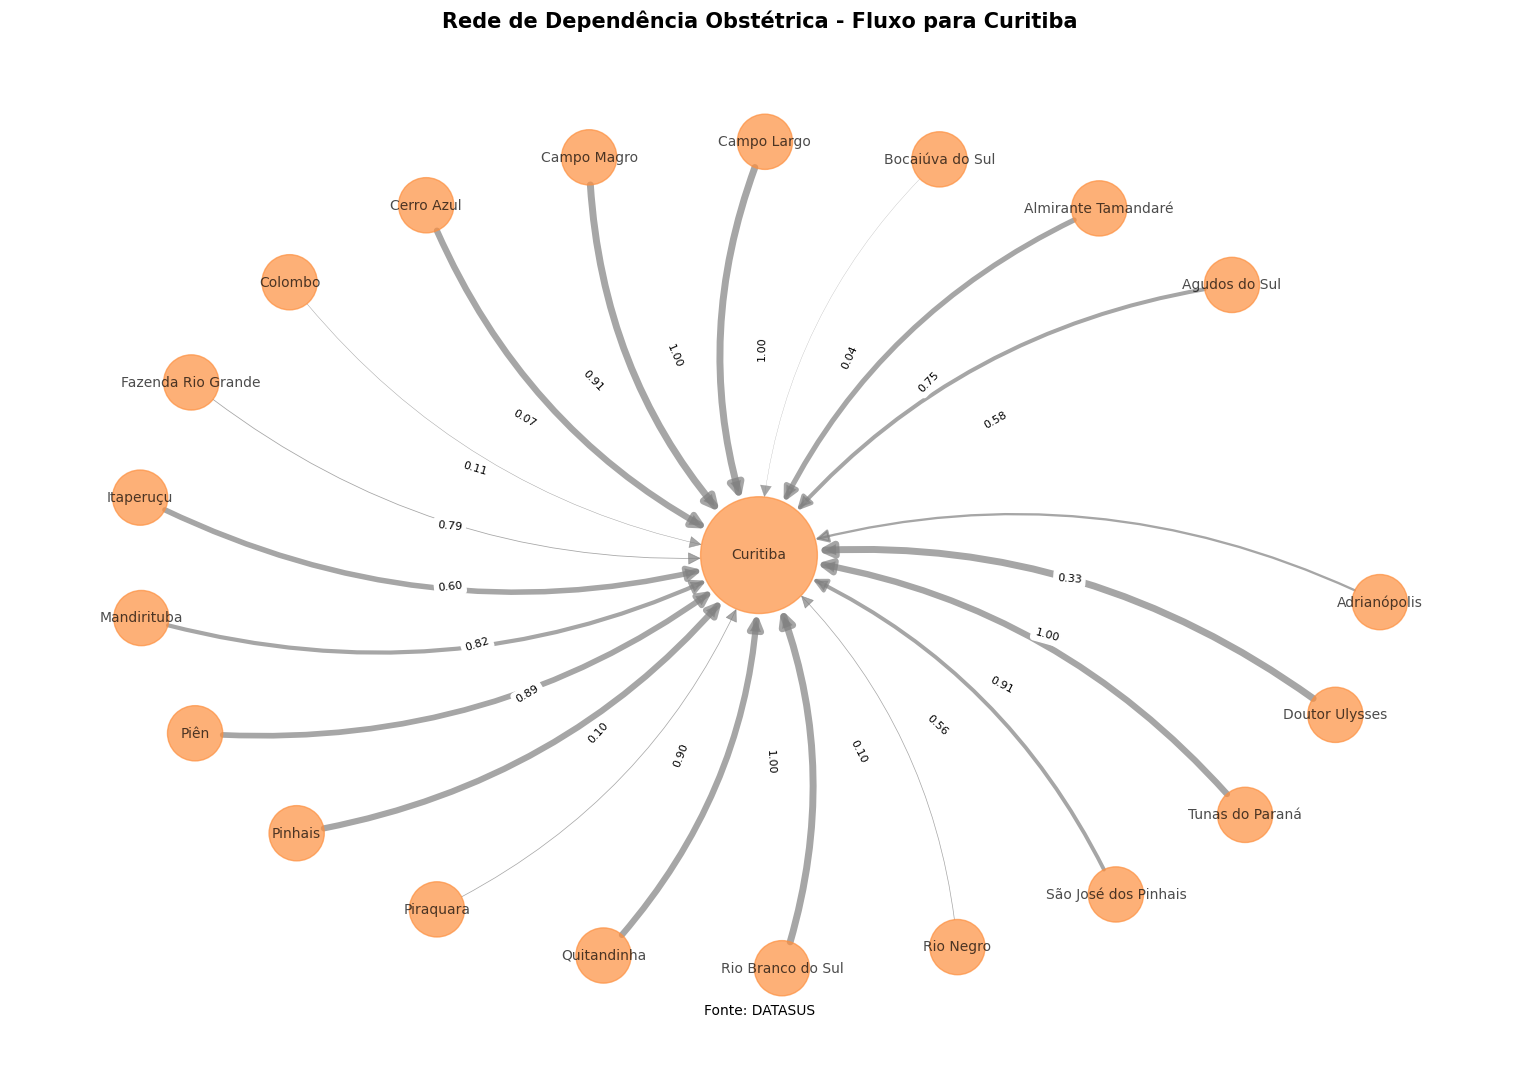

In [27]:
plt.figure(figsize=(15, 10))

G1_1 = nx.from_pandas_edgelist(
    grafo_edges1_1,
    'Municipio_x',
    'Municipio_y',
    ['dep_curitiba'],
    create_using=nx.DiGraph()
)

edge_weights = [G1_1[u][v]['dep_curitiba'] * 5 for u, v in G1_1.edges()]

node_weights = []
for node in G1_1.nodes():
    node_weights.append(centrality_df_1.loc[node, 'centrality']*10000)

pos_1 = nx.kamada_kawai_layout(G1_1)

nx.draw(G1_1, pos_1,
        node_size=node_weights,
        width=edge_weights,
        with_labels=True,
        node_color='#FD8F3E',
        font_size=10,
        arrowsize=20,
        edge_color='gray',
        alpha=0.7,
        connectionstyle='arc3, rad = 0.2')

labels_formatados = {
    (u, v): f"{d['dep_curitiba']:.2f}"
    for u, v, d in G1_1.edges(data=True)
}

nx.draw_networkx_edge_labels(G1_1, pos_1, edge_labels=labels_formatados, font_size=8)

plt.title('Rede de Dependência Obstétrica - Fluxo para Curitiba', pad=20, fontsize=15, fontweight='bold')
plt.figtext(0.5, 0.04, 'Fonte: DATASUS', ha="center", fontsize=10)

plt.show()

In [28]:
df_mapa = gpd.read_file(GEO_DIR / 'Limites_Municipais_2020.shp')
df_mapa

,gid,codibge,nome,geometry
0,399,4128807,Xambre,"POLYGON ((-53.53611 -23.81954, -53.5366 -23.81..."
1,93,4106852,Cruzmaltina,"POLYGON ((-51.38116 -24.05889, -51.38115 -24.0..."
2,348,4125407,Sao Jose Da Boa Vista,"POLYGON ((-49.53659 -23.92793, -49.53674 -23.9..."
3,331,4124004,Santana Do Itarare,"POLYGON ((-49.6312 -23.84646, -49.63154 -23.84..."
4,359,4126207,Sapopema,"POLYGON ((-50.44879 -23.75585, -50.44878 -23.7..."
...,...,...,...,...
394,238,4117214,Nova Santa Barbara,"POLYGON ((-50.77044 -23.61442, -50.77055 -23.6..."
395,296,4121307,Rancho Alegre,"POLYGON ((-50.85481 -23.1117, -50.85514 -23.11..."
396,364,4126405,Sertaneja,"POLYGON ((-50.84225 -23.11003, -50.84237 -23.1..."
397,141,4109807,Ibipora,"POLYGON ((-50.94779 -23.10645, -50.94751 -23.1..."


In [29]:
df_mapa["codibge"] = pd.to_numeric(df_mapa["codibge"], errors='coerce')
df_mapa['codibge'] = df_mapa['codibge'] // 10
df_mapa

,gid,codibge,nome,geometry
0,399,412880,Xambre,"POLYGON ((-53.53611 -23.81954, -53.5366 -23.81..."
1,93,410685,Cruzmaltina,"POLYGON ((-51.38116 -24.05889, -51.38115 -24.0..."
2,348,412540,Sao Jose Da Boa Vista,"POLYGON ((-49.53659 -23.92793, -49.53674 -23.9..."
3,331,412400,Santana Do Itarare,"POLYGON ((-49.6312 -23.84646, -49.63154 -23.84..."
4,359,412620,Sapopema,"POLYGON ((-50.44879 -23.75585, -50.44878 -23.7..."
...,...,...,...,...
394,238,411721,Nova Santa Barbara,"POLYGON ((-50.77044 -23.61442, -50.77055 -23.6..."
395,296,412130,Rancho Alegre,"POLYGON ((-50.85481 -23.1117, -50.85514 -23.11..."
396,364,412640,Sertaneja,"POLYGON ((-50.84225 -23.11003, -50.84237 -23.1..."
397,141,410980,Ibipora,"POLYGON ((-50.94779 -23.10645, -50.94751 -23.1..."


In [30]:
df_mapa = df_mapa[
    df_mapa["codibge"].astype(int).isin(array_mun)
]

df_mapa

,gid,codibge,nome,geometry
14,382,412788,Tunas Do Parana,"POLYGON ((-48.83744 -24.86856, -48.73231 -24.8..."
15,2,410020,Adrianopolis,"POLYGON ((-48.73231 -24.86648, -48.83744 -24.8..."
18,183,411320,Lapa,"POLYGON ((-49.64351 -25.89355, -49.64328 -25.8..."
21,22,410180,Araucaria,"POLYGON ((-49.36976 -25.78858, -49.36974 -25.7..."
36,94,410690,Curitiba,"POLYGON ((-49.3743 -25.5133, -49.37424 -25.513..."
37,59,410420,Campo Largo,"POLYGON ((-49.38629 -25.4464, -49.38611 -25.44..."
39,289,412080,Quatro Barras,"POLYGON ((-49.12026 -25.37789, -49.12032 -25.3..."
40,79,410580,Colombo,"POLYGON ((-49.12405 -25.37061, -49.12401 -25.3..."
94,73,410520,Cerro Azul,"POLYGON ((-49.13049 -24.68161, -49.13102 -24.6..."
251,3,410030,Agudos Do Sul,"POLYGON ((-49.36069 -25.95191, -49.36059 -25.9..."


<Axes: >

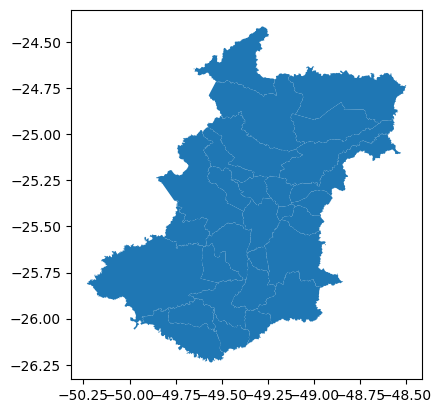

In [31]:
df_mapa.plot()

In [32]:
#df_mapa.to_file(GEO_DIR / 'Limites_Municipais_2020_02RS.shp')

In [33]:
grafo_edges1_map = grafo_edges1.copy()
grafo_edges1_map

,MUNIC_RES,MUNIC_MOV,internacoes,fora,dep_curitiba,Regional de Saude_x,Municipio_x,Codigo_x,Regional de Saude_y,Municipio_y,Codigo_y
0,410020,410690,2,6.0,0.333333,2,Adrianópolis,410020,2,Curitiba,410690
1,410030,410690,11,19.0,0.578947,2,Agudos do Sul,410030,2,Curitiba,410690
2,410040,410690,104,139.0,0.748201,2,Almirante Tamandaré,410040,2,Curitiba,410690
3,410310,410690,1,26.0,0.038462,2,Bocaiúva do Sul,410310,2,Curitiba,410690
4,410420,410690,3,3.0,1.000000,2,Campo Largo,410420,2,Curitiba,410690
5,410425,410690,20,20.0,1.000000,2,Campo Magro,410425,2,Curitiba,410690
6,410520,410690,20,22.0,0.909091,2,Cerro Azul,410520,2,Curitiba,410690
7,410580,410690,4,55.0,0.072727,2,Colombo,410580,2,Curitiba,410690
8,410765,410690,8,70.0,0.114286,2,Fazenda Rio Grande,410765,2,Curitiba,410690
9,411125,410690,19,24.0,0.791667,2,Itaperuçu,411125,2,Curitiba,410690


In [34]:
grafo_edges1_map.dtypes

,0
MUNIC_RES,int64
MUNIC_MOV,int64
internacoes,int64
fora,float64
dep_curitiba,float64
Regional de Saude_x,int64
Municipio_x,object
Codigo_x,int64
Regional de Saude_y,int64
Municipio_y,object


In [35]:
G_map = nx.convert_matrix.from_pandas_edgelist(grafo_edges1_map, 'Codigo_x', 'Codigo_y', ['dep_curitiba'])
list(G_map.nodes())

[410020,
 410690,
 410030,
 410040,
 410310,
 410420,
 410425,
 410520,
 410580,
 410765,
 411125,
 411430,
 411910,
 411915,
 411950,
 412120,
 412220,
 412230,
 412550,
 412788,
 412863]

In [36]:
grafo_edges1_map_1 = grafo_edges1_map.copy()

grafo_edges1_map_1['MUNIC_RES'] = grafo_edges1_map_1['MUNIC_RES'].astype(str)
grafo_edges1_map_1['MUNIC_MOV'] = grafo_edges1_map_1['MUNIC_MOV'].astype(str)
grafo_edges1_map_1['Codigo_x'] = grafo_edges1_map_1['Codigo_x'].astype(str)
grafo_edges1_map_1['Codigo_y'] = grafo_edges1_map_1['Codigo_y'].astype(str)

grafo_edges1_map_1.dtypes

,0
MUNIC_RES,object
MUNIC_MOV,object
internacoes,int64
fora,float64
dep_curitiba,float64
Regional de Saude_x,int64
Municipio_x,object
Codigo_x,object
Regional de Saude_y,int64
Municipio_y,object


In [37]:
G_map_1 = nx.convert_matrix.from_pandas_edgelist(grafo_edges1_map_1, 'Codigo_x', 'Codigo_y', ['dep_curitiba'])
list(G_map_1.nodes())

['410020',
 '410690',
 '410030',
 '410040',
 '410310',
 '410420',
 '410425',
 '410520',
 '410580',
 '410765',
 '411125',
 '411430',
 '411910',
 '411915',
 '411950',
 '412120',
 '412220',
 '412230',
 '412550',
 '412788',
 '412863']

In [38]:
probs = [i['dep_curitiba'] for i in dict(G_map.edges).values()]
labels = [i for i in dict(G_map.nodes).keys()]
labels = {i:i for i in dict(G_map.nodes).keys()}

grafo_edges1_map

,MUNIC_RES,MUNIC_MOV,internacoes,fora,dep_curitiba,Regional de Saude_x,Municipio_x,Codigo_x,Regional de Saude_y,Municipio_y,Codigo_y
0,410020,410690,2,6.0,0.333333,2,Adrianópolis,410020,2,Curitiba,410690
1,410030,410690,11,19.0,0.578947,2,Agudos do Sul,410030,2,Curitiba,410690
2,410040,410690,104,139.0,0.748201,2,Almirante Tamandaré,410040,2,Curitiba,410690
3,410310,410690,1,26.0,0.038462,2,Bocaiúva do Sul,410310,2,Curitiba,410690
4,410420,410690,3,3.0,1.000000,2,Campo Largo,410420,2,Curitiba,410690
5,410425,410690,20,20.0,1.000000,2,Campo Magro,410425,2,Curitiba,410690
6,410520,410690,20,22.0,0.909091,2,Cerro Azul,410520,2,Curitiba,410690
7,410580,410690,4,55.0,0.072727,2,Colombo,410580,2,Curitiba,410690
8,410765,410690,8,70.0,0.114286,2,Fazenda Rio Grande,410765,2,Curitiba,410690
9,411125,410690,19,24.0,0.791667,2,Itaperuçu,411125,2,Curitiba,410690


In [39]:
with open(GNN_FILE, "wb") as f:
    pickle.dump(G_map_1, f)

In [40]:
centrality = nx.eigenvector_centrality(G_map)
centrality_df = pd.DataFrame(centrality.keys(),columns=['municipio'])
centrality_df['centrality'] = centrality.values()
centrality_df = centrality_df.set_index('municipio')

centrality_df.head()

,centrality
municipio,
410020,0.158114
410690,0.707105
410030,0.158114
410040,0.158114
410310,0.158114


In [41]:
transition_matrix_sorted = grafo_edges1_map.sort_values(by='dep_curitiba', ascending=False).reset_index()

top_edges = transition_matrix_sorted.index >= 0
main_edges = list(transition_matrix_sorted[top_edges].drop(columns=['index', 'MUNIC_RES',	'MUNIC_MOV',	'internacoes',	'fora', 'dep_curitiba', 'Regional de Saude_x',	'Municipio_x', 'Regional de Saude_y',	'Municipio_y']).to_records(index=False))
main_edges = [(int(reg[0]), int(reg[1])) for reg in main_edges]

main_edges

[(412220, 410690),
 (412863, 410690),
 (410425, 410690),
 (410420, 410690),
 (410520, 410690),
 (412788, 410690),
 (412120, 410690),
 (411915, 410690),
 (411910, 410690),
 (411125, 410690),
 (410040, 410690),
 (411430, 410690),
 (410030, 410690),
 (412550, 410690),
 (410020, 410690),
 (410765, 410690),
 (411950, 410690),
 (412230, 410690),
 (410580, 410690),
 (410310, 410690)]

In [42]:
main_edges_values = []

for x in transition_matrix_sorted[top_edges]['dep_curitiba']:
    main_edges_values.append(x)

main_edges_values

[1.0,
 1.0,
 1.0,
 1.0,
 0.9090909090909091,
 0.9090909090909091,
 0.9,
 0.8888888888888888,
 0.8181818181818182,
 0.7916666666666666,
 0.7482014388489209,
 0.6,
 0.5789473684210527,
 0.5555555555555556,
 0.3333333333333333,
 0.11428571428571428,
 0.1037037037037037,
 0.1,
 0.07272727272727272,
 0.038461538461538464]

In [43]:
weight = []
for node in G_map.nodes():
    weight.append(centrality_df.loc[node, 'centrality']*100000)

In [44]:
df_coords = df_mapa.copy()
df_coords['coords'] = df_mapa['geometry'].apply(lambda x: x.representative_point().coords[:])
df_coords['coords'] = [coords[0] for coords in df_coords['coords']]

df_coords[['latitude', 'longitude']] = pd.DataFrame(df_coords['coords'].tolist(), index=df_coords.index)

df_coords['codibgeindex'] = df_coords['codibge']
df_coords = df_coords.set_index("codibgeindex")

df_coords

,gid,codibge,nome,geometry,coords,latitude,longitude
codibgeindex,,,,,,,
412788,382,412788,Tunas Do Parana,"POLYGON ((-48.83744 -24.86856, -48.73231 -24.8...","(-48.88150910726587, -24.939746093199528)",-48.881509,-24.939746
410020,2,410020,Adrianopolis,"POLYGON ((-48.73231 -24.86648, -48.83744 -24.8...","(-48.798026302634966, -24.788651343415033)",-48.798026,-24.788651
411320,183,411320,Lapa,"POLYGON ((-49.64351 -25.89355, -49.64328 -25.8...","(-49.88227513258791, -25.80111021888539)",-49.882275,-25.801110
410180,22,410180,Araucaria,"POLYGON ((-49.36976 -25.78858, -49.36974 -25.7...","(-49.45145052822423, -25.63378849945028)",-49.451451,-25.633788
410690,94,410690,Curitiba,"POLYGON ((-49.3743 -25.5133, -49.37424 -25.513...","(-49.284503557082274, -25.494977982975133)",-49.284504,-25.494978
410420,59,410420,Campo Largo,"POLYGON ((-49.38629 -25.4464, -49.38611 -25.44...","(-49.69262492298018, -25.266149503480044)",-49.692625,-25.266150
412080,289,412080,Quatro Barras,"POLYGON ((-49.12026 -25.37789, -49.12032 -25.3...","(-49.01940709912401, -25.373420797634335)",-49.019407,-25.373421
410580,79,410580,Colombo,"POLYGON ((-49.12405 -25.37061, -49.12401 -25.3...","(-49.19215540026744, -25.30952944561117)",-49.192155,-25.309529
410520,73,410520,Cerro Azul,"POLYGON ((-49.13049 -24.68161, -49.13102 -24.6...","(-49.24353983964053, -24.88445725980296)",-49.243540,-24.884457


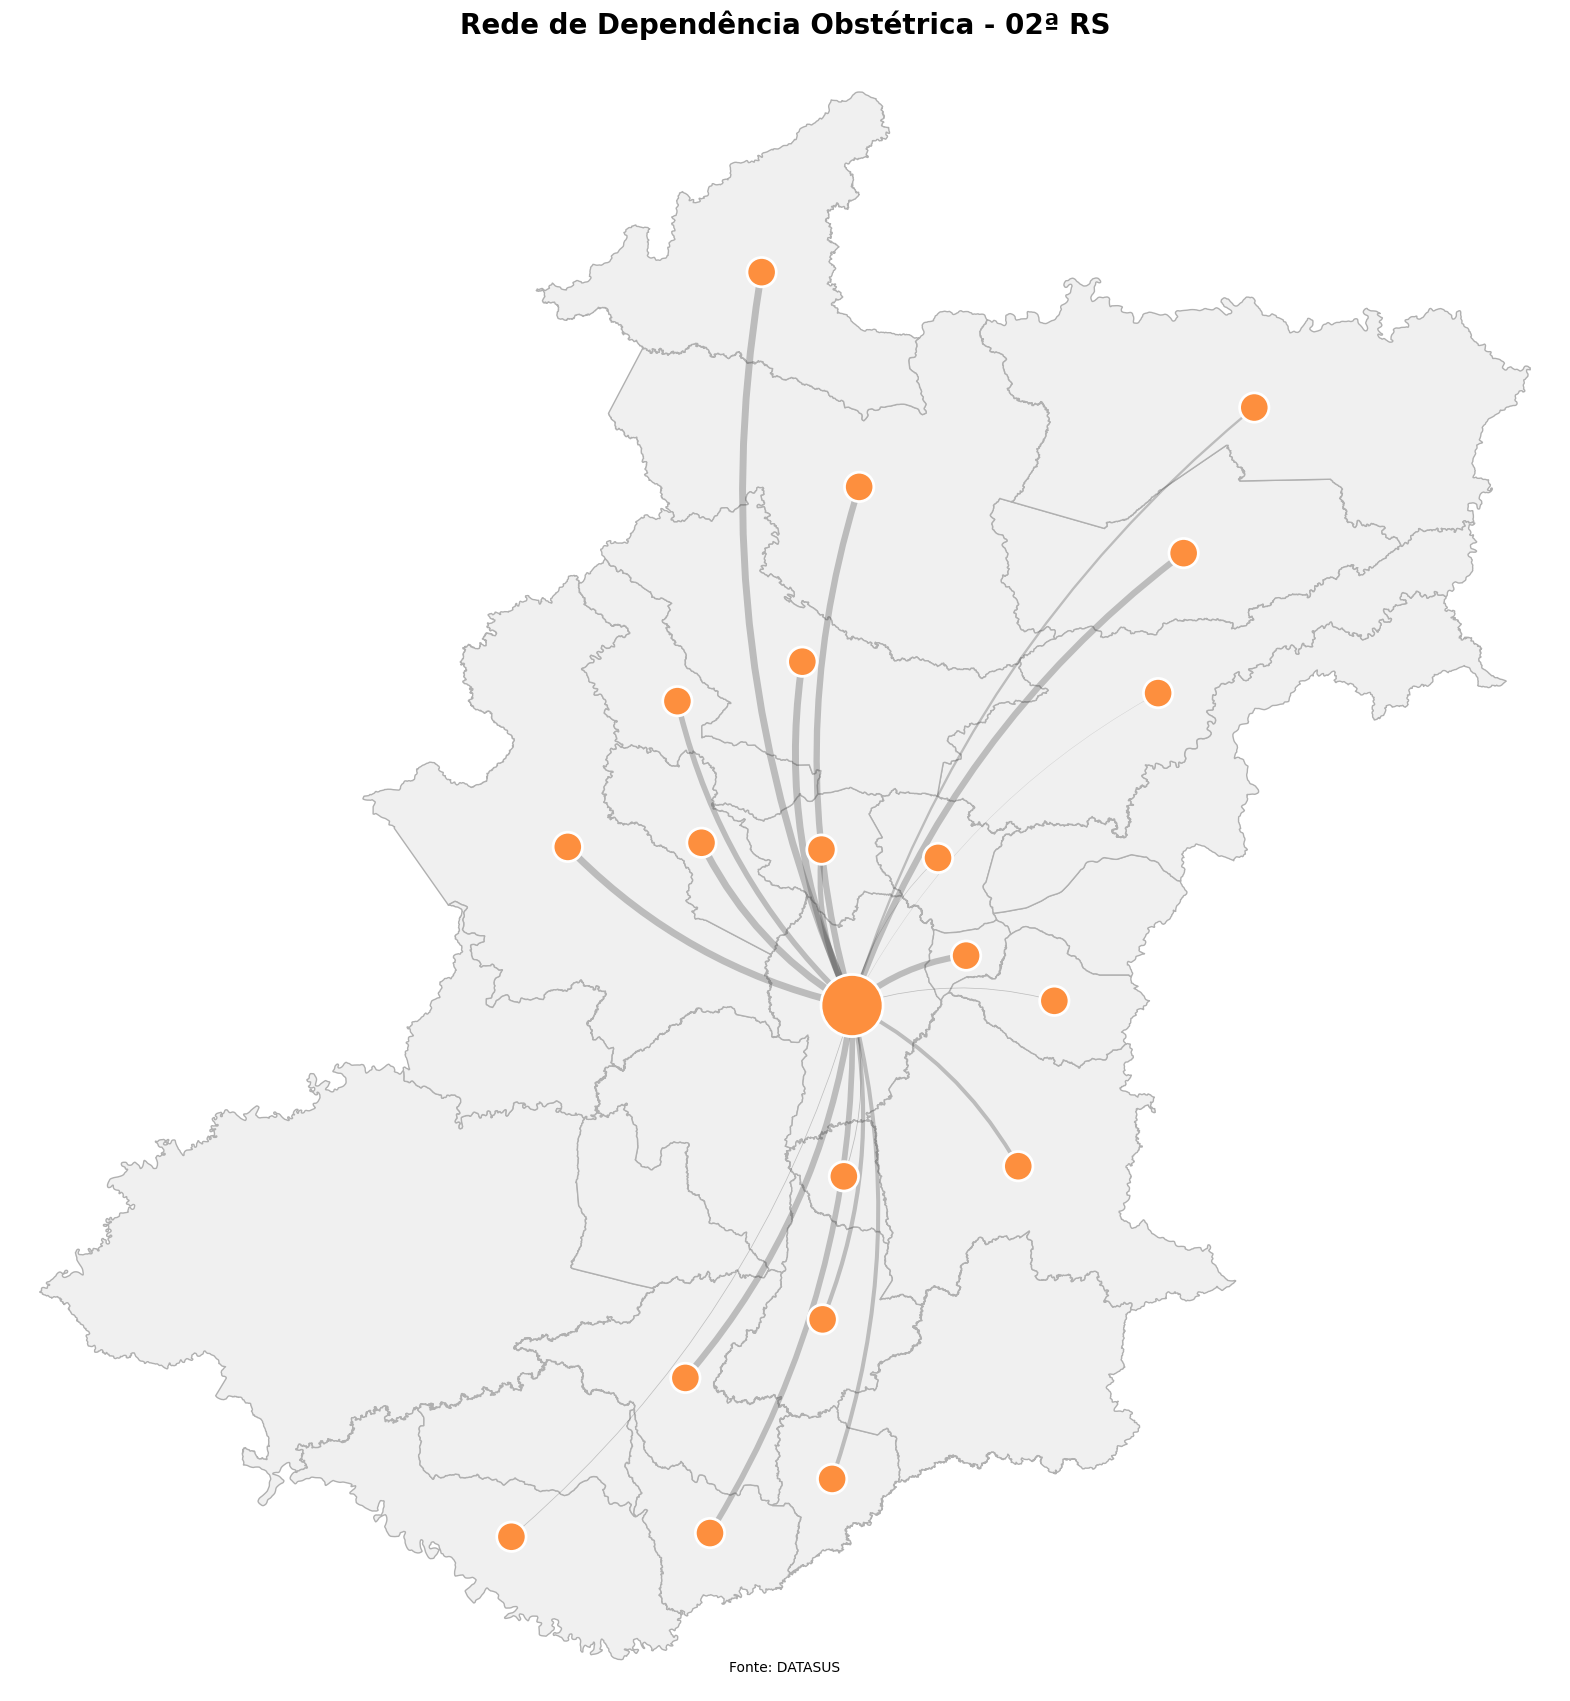

In [45]:
# 1. Configurar a figura
fig, ax = plt.subplots(figsize=(20, 30))

# 2. O mapa de fundo
df_coords.plot(ax=ax, color='#F0F0F0', edgecolor='#B0B0B0', linewidth=1)

# 3. Posições via centroide
pos = {int(idx): (row.geometry.centroid.x, row.geometry.centroid.y)
       for idx, row in df_coords.iterrows()}

# 4. Normalização dos tamanhos
max_w = max(weight) if len(weight) > 0 else 1
# Definindo que o maior nó terá tamanho 2000
scaled_node_size = [(w / max_w) * 2000 for w in weight]

# Mesma lógica é aplicada para as linhas
max_v = max(main_edges_values) if len(main_edges_values) > 0 else 1
scaled_edge_width = [(v / max_v) * 5 for v in main_edges_values]

# 5. Desenho
# Desenhando as arestas
nx.draw_networkx_edges(G_map, pos,
                       edgelist=main_edges,
                       width=scaled_edge_width,
                       edge_color='#444444',
                       alpha=0.3,
                       ax=ax,
                       arrows=True,
                       arrowsize=30,
                       connectionstyle='arc3,rad=0.15')

# Desenhando os nós
nx.draw_networkx_nodes(G_map, pos,
                       node_size=scaled_node_size,
                       node_color='#FD8F3E',
                       edgecolors='white',
                       linewidths=2,
                       ax=ax)

# 6. Fixando os limites
minx, miny, maxx, maxy = df_coords.total_bounds
padx = (maxx - minx) * 0.02
pady = (maxy - miny) * 0.02

ax.set_xlim(minx - padx, maxx + padx)
ax.set_ylim(miny - pady, maxy + pady)

ax.set_title('Rede de Dependência Obstétrica - 02ª RS', fontsize=20, pad=20, fontweight='bold')
ax.annotate('Fonte: DATASUS', xy=(0.5, 0.01), xycoords='axes fraction', ha='center', va='bottom', fontsize=10)
ax.axis('off')

plt.show()

In [46]:
G_road = ox.load_graphml(GRAPHML_FILE)

In [47]:
municipios = {
    #"Adrianopolis": (-24.661, -48.992),
    #"Campina_Grande_do_Sul": (-25.305, -49.055),
    "Campo_Largo": (-25.459, -49.528),
    "Campo_Magro": (-25.368, -49.450),
    #"Cerro_Azul": (-24.822, -49.261),
    "Doutor_Ulysses": (-24.566, -49.420),
    #"Itaperucu": (-25.220, -49.176),
    #"Pinhais": (-25.444, -49.192),
    #"Quitandinha": (-25.839, -49.497),
    "Rio_Branco_do_Sul": (-25.189, -49.314),
    #"Sao_Jose_dos_Pinhais": (-25.531, -49.203),
    #"Tunas_do_Parana": (-24.973, -49.085)
}

destino = (-25.429, -49.271)  # Curitiba

rotas = {}

for nome, origem in municipios.items():
    orig_node = ox.distance.nearest_nodes(G_road, origem[1], origem[0])
    dest_node = ox.distance.nearest_nodes(G_road, destino[1], destino[0])

    route = nx.shortest_path(G_road, orig_node, dest_node, weight="length")
    rotas[nome] = route

list(rotas.keys())

['Campo_Largo', 'Campo_Magro', 'Doutor_Ulysses', 'Rio_Branco_do_Sul']

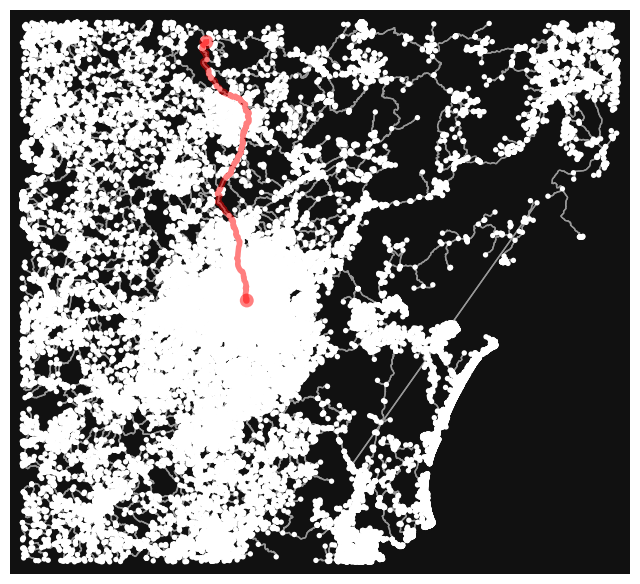

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [48]:
ox.plot_graph_route(G_road, rotas["Doutor_Ulysses"])

In [49]:
resultados_rotas = []

for nome, route in rotas.items():
    distancia_m = sum(ox.routing.route_to_gdf(G_road, route)["length"])

    resultados_rotas.append({
        "municipio": nome,
        "distancia_km": distancia_m / 1000
    })

df_rotas = pd.DataFrame(resultados_rotas)
df_rotas

,municipio,distancia_km
0,Campo_Largo,28.708794
1,Campo_Magro,21.488506
2,Doutor_Ulysses,131.949048
3,Rio_Branco_do_Sul,30.373993


In [50]:
G_road = ox.add_edge_speeds(G_road)
G_road = ox.add_edge_travel_times(G_road)

In [51]:
resultados_rotas = []

for municipio, route in rotas.items():

    gdf_rota = ox.routing.route_to_gdf(G_road, route)

    distancia_km = gdf_rota["length"].sum() / 1000
    tempo_min = gdf_rota["travel_time"].sum() / 60

    rodovias = set()

    for ref in gdf_rota["ref"].dropna():
        if isinstance(ref, list):
            rodovias.update(ref)
        else:
            rodovias.add(ref)

    resultados_rotas.append({
        "municipio": municipio,
        "distancia_km": round(distancia_km, 1),
        "tempo_min": round(tempo_min, 1),
        "rodovias": list(rodovias)
    })

df_rotas = pd.DataFrame(resultados_rotas)

df_rotas

,municipio,distancia_km,tempo_min,rodovias
0,Campo_Largo,28.7,22.9,[BR-277]
1,Campo_Magro,21.5,23.9,[PR-090]
2,Doutor_Ulysses,131.9,146.3,[PR-092]
3,Rio_Branco_do_Sul,30.4,33.5,[PR-092]


In [52]:
def limpar_rodovias(lista):

    rodovias_limpa = []

    for r in lista:

        if isinstance(r, str):

            partes = r.split(";")

            for p in partes:
                rodovias_limpa.append(p.strip())

    return sorted(set(rodovias_limpa))


df_rotas["rodovias"] = df_rotas["rodovias"].apply(limpar_rodovias)

df_rotas

,municipio,distancia_km,tempo_min,rodovias
0,Campo_Largo,28.7,22.9,[BR-277]
1,Campo_Magro,21.5,23.9,[PR-090]
2,Doutor_Ulysses,131.9,146.3,[PR-092]
3,Rio_Branco_do_Sul,30.4,33.5,[PR-092]


In [53]:
df_rotas["corredor_principal"] = df_rotas["rodovias"].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
)

df_rotas

,municipio,distancia_km,tempo_min,rodovias,corredor_principal
0,Campo_Largo,28.7,22.9,[BR-277],BR-277
1,Campo_Magro,21.5,23.9,[PR-090],PR-090
2,Doutor_Ulysses,131.9,146.3,[PR-092],PR-092
3,Rio_Branco_do_Sul,30.4,33.5,[PR-092],PR-092


In [54]:
indicadores_selecionados = indic1_2[[
    "Municipio",
    "total",
    "fora",
    "export_pct",
    "para_curitiba",
    "dep_curitiba"
]].copy()

indicadores_selecionados["municipio"] = (
    indicadores_selecionados["Municipio"]
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
    .str.replace(" ", "_", regex=False)
)

indicadores_selecionados

,Municipio,total,fora,export_pct,para_curitiba,dep_curitiba,municipio
0,Adrianópolis,6,6.0,1.000000,2.0,0.333333,Adrianopolis
1,Agudos do Sul,19,19.0,1.000000,11.0,0.578947,Agudos_do_Sul
2,Almirante Tamandaré,139,139.0,1.000000,104.0,0.748201,Almirante_Tamandare
3,Araucária,119,2.0,0.016807,0.0,0.000000,Araucaria
4,Balsa Nova,17,17.0,1.000000,0.0,0.000000,Balsa_Nova
5,Bocaiúva do Sul,26,26.0,1.000000,1.0,0.038462,Bocaiuva_do_Sul
6,Campina Grande do Sul,29,0.0,0.000000,0.0,0.000000,Campina_Grande_do_Sul
7,Campo do Tenente,6,6.0,1.000000,0.0,0.000000,Campo_do_Tenente
8,Campo Largo,151,3.0,0.019868,3.0,1.000000,Campo_Largo
9,Campo Magro,20,20.0,1.000000,20.0,1.000000,Campo_Magro


In [55]:
tabela_final = df_rotas.merge(
    indicadores_selecionados.drop(columns="Municipio"),
    on="municipio",
    how="left"
)

tabela_final

,municipio,distancia_km,tempo_min,rodovias,corredor_principal,total,fora,export_pct,para_curitiba,dep_curitiba
0,Campo_Largo,28.7,22.9,[BR-277],BR-277,151,3.0,0.019868,3.0,1.0
1,Campo_Magro,21.5,23.9,[PR-090],PR-090,20,20.0,1.000000,20.0,1.0
2,Doutor_Ulysses,131.9,146.3,[PR-092],PR-092,6,6.0,1.000000,6.0,1.0
3,Rio_Branco_do_Sul,30.4,33.5,[PR-092],PR-092,31,10.0,0.322581,10.0,1.0


In [56]:
tabela_final["indice_vulnerabilidade_dist"] = (
    tabela_final["dep_curitiba"] * tabela_final["distancia_km"]
)

tabela_final["indice_vulnerabilidade_tempo"] = (
    tabela_final["dep_curitiba"] * tabela_final["tempo_min"]
)

tabela_final.sort_values("indice_vulnerabilidade_tempo", ascending=False)

,municipio,distancia_km,tempo_min,rodovias,corredor_principal,total,fora,export_pct,para_curitiba,dep_curitiba,indice_vulnerabilidade_dist,indice_vulnerabilidade_tempo
2,Doutor_Ulysses,131.9,146.3,[PR-092],PR-092,6,6.0,1.000000,6.0,1.0,131.9,146.3
3,Rio_Branco_do_Sul,30.4,33.5,[PR-092],PR-092,31,10.0,0.322581,10.0,1.0,30.4,33.5
1,Campo_Magro,21.5,23.9,[PR-090],PR-090,20,20.0,1.000000,20.0,1.0,21.5,23.9
0,Campo_Largo,28.7,22.9,[BR-277],BR-277,151,3.0,0.019868,3.0,1.0,28.7,22.9


In [57]:
tabela_final = tabela_final[[
    "municipio",
    "total",
    "fora",
    "export_pct",
    "para_curitiba",
    "dep_curitiba",
    "distancia_km",
    "tempo_min",
    "corredor_principal",
    "indice_vulnerabilidade_dist",
    "indice_vulnerabilidade_tempo"
]].sort_values("indice_vulnerabilidade_tempo", ascending=False)

tabela_final

,municipio,total,fora,export_pct,para_curitiba,dep_curitiba,distancia_km,tempo_min,corredor_principal,indice_vulnerabilidade_dist,indice_vulnerabilidade_tempo
2,Doutor_Ulysses,6,6.0,1.000000,6.0,1.0,131.9,146.3,PR-092,131.9,146.3
3,Rio_Branco_do_Sul,31,10.0,0.322581,10.0,1.0,30.4,33.5,PR-092,30.4,33.5
1,Campo_Magro,20,20.0,1.000000,20.0,1.0,21.5,23.9,PR-090,21.5,23.9
0,Campo_Largo,151,3.0,0.019868,3.0,1.0,28.7,22.9,BR-277,28.7,22.9


In [58]:
tabela_resultado = tabela_final.copy()

tabela_resultado["dep_curitiba_pct"] = (tabela_resultado["dep_curitiba"] * 100).round(1)
tabela_resultado["export_pct"] = tabela_resultado["export_pct"].round(1)

tabela_resultado["perfil_acesso"] = pd.cut(
    tabela_resultado["tempo_min"],
    bins=[0, 40, 90, float("inf")],
    labels=["curto", "intermediario", "longo"]
)

tabela_resultado["perfil_vulnerabilidade"] = pd.cut(
    tabela_resultado["indice_vulnerabilidade_tempo"],
    bins=[0, 20, 60, float("inf")],
    labels=["baixa", "moderada", "alta"]
)

tabela_resultado = tabela_resultado[[
    "municipio",
    "dep_curitiba_pct",
    "distancia_km",
    "tempo_min",
    "corredor_principal",
    "perfil_acesso",
    "perfil_vulnerabilidade",
    "indice_vulnerabilidade_tempo"
]].sort_values("indice_vulnerabilidade_tempo", ascending=False)

tabela_resultado

,municipio,dep_curitiba_pct,distancia_km,tempo_min,corredor_principal,perfil_acesso,perfil_vulnerabilidade,indice_vulnerabilidade_tempo
2,Doutor_Ulysses,100.0,131.9,146.3,PR-092,longo,alta,146.3
3,Rio_Branco_do_Sul,100.0,30.4,33.5,PR-092,curto,moderada,33.5
1,Campo_Magro,100.0,21.5,23.9,PR-090,curto,moderada,23.9
0,Campo_Largo,100.0,28.7,22.9,BR-277,curto,moderada,22.9


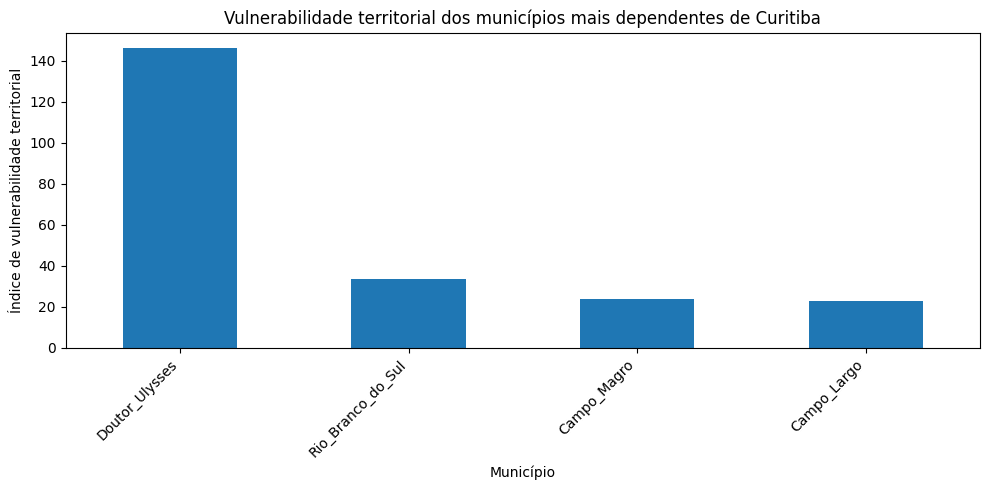

In [59]:
ax = tabela_resultado.sort_values("indice_vulnerabilidade_tempo", ascending=False).plot(
    x="municipio",
    y="indice_vulnerabilidade_tempo",
    kind="bar",
    legend=False,
    figsize=(10, 5)
)

plt.ylabel("Índice de vulnerabilidade territorial")
plt.xlabel("Município")
plt.title("Vulnerabilidade territorial dos municípios mais dependentes de Curitiba")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

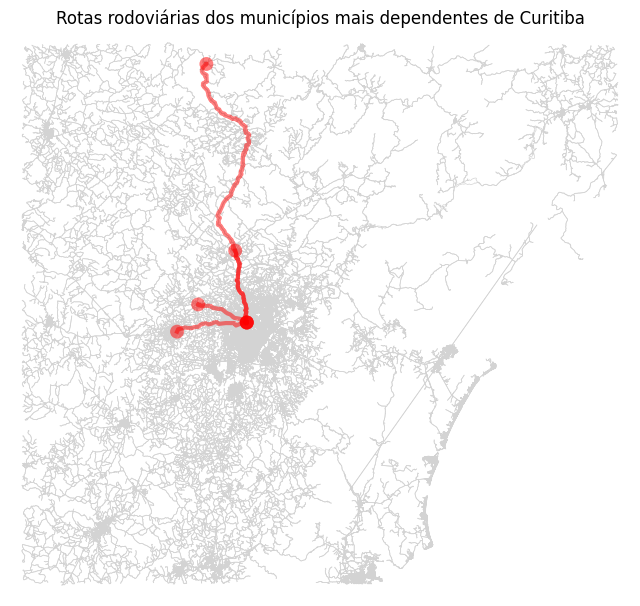

In [60]:
fig, ax = ox.plot_graph(
    G_road,
    bgcolor="white",
    node_size=0,
    edge_color="lightgray",
    edge_linewidth=0.5,
    show=False,
    close=False
)

for nome, route in rotas.items():
    ox.plot_graph_route(
        G_road,
        route,
        route_color="red",
        route_linewidth=3,
        ax=ax,
        show=False,
        close=False
    )

plt.title("Rotas rodoviárias dos municípios mais dependentes de Curitiba")
plt.show()

In [61]:
# Total de internações obstétricas analisadas
total_internacoes = df_obst.shape[0]

# Número de municípios de residência na 2ª RS presentes nos dados
num_municipios = df_obst["MUNIC_RES"].nunique()

# Número de pares origem-destino distintos
num_pares_od = (
    df_obst[["MUNIC_RES", "MUNIC_MOV"]]
    .drop_duplicates()
    .shape[0]
)

# Número de internações realizadas em Curitiba de pacientes residentes em outros municípios
codigo_curitiba = 410690  # Curitiba
n_external_curitiba = df_obst[
    (df_obst["MUNIC_MOV"] == codigo_curitiba) &
    (df_obst["MUNIC_RES"] != codigo_curitiba)
].shape[0]

total_internacoes, num_municipios, num_pares_od, n_external_curitiba

(2902, 29, 74, 301)

In [62]:
## Montagem do dataframe para rede neural ##

municipios = {
    "Adrianopolis": (-24.661, -48.992),
    "Agudos_do_Sul": (-25.989, -49.334),
    "Almirante_Tamandare": (-25.318, -49.310),
    "Araucaria": (-25.592, -49.404),
    "Balsa_Nova": (-25.583, -49.632),
    "Bocaiuva_do_Sul": (-25.206, -49.114),
    "Campina_Grande_do_Sul": (-25.305, -49.055),
    "Campo_do_Tenente": (-25.979, -49.685),
    "Campo_Largo": (-25.459, -49.529),
    "Campo_Magro": (-25.368, -49.450),
    "Cerro_Azul": (-24.823, -49.260),
    "Colombo": (-25.292, -49.224),
    "Contenda": (-25.678, -49.536),
    "Doutor_Ulysses": (-24.566, -49.420),
    "Fazenda_Rio_Grande": (-25.662, -49.307),
    "Itaperucu": (-25.220, -49.176),
    "Lapa": (-25.769, -49.716),
    "Mandirituba": (-25.777, -49.327),
    "Pien": (-26.096, -49.429),
    "Pinhais": (-25.444, -49.192),
    "Piraquara": (-25.443, -49.062),
    "Quatro_Barras": (-25.366, -49.076),
    "Quitandinha": (-25.839, -49.497),
    "Rio_Branco_do_Sul": (-25.189, -49.314),
    "Rio_Negro": (-26.105, -49.798),
    "Sao_Jose_dos_Pinhais": (-25.531, -49.203),
    "Tijucas_do_Sul": (-25.925, -49.178),
    "Tunas_do_Parana": (-24.973, -49.085)
}

destino = (-25.429, -49.271)  # Curitiba

rotas = {}

for nome, origem in municipios.items():
    orig_node = ox.distance.nearest_nodes(G_road, origem[1], origem[0])
    dest_node = ox.distance.nearest_nodes(G_road, destino[1], destino[0])

    route = nx.shortest_path(G_road, orig_node, dest_node, weight="length")
    rotas[nome] = route

list(rotas.keys())

['Adrianopolis',
 'Agudos_do_Sul',
 'Almirante_Tamandare',
 'Araucaria',
 'Balsa_Nova',
 'Bocaiuva_do_Sul',
 'Campina_Grande_do_Sul',
 'Campo_do_Tenente',
 'Campo_Largo',
 'Campo_Magro',
 'Cerro_Azul',
 'Colombo',
 'Contenda',
 'Doutor_Ulysses',
 'Fazenda_Rio_Grande',
 'Itaperucu',
 'Lapa',
 'Mandirituba',
 'Pien',
 'Pinhais',
 'Piraquara',
 'Quatro_Barras',
 'Quitandinha',
 'Rio_Branco_do_Sul',
 'Rio_Negro',
 'Sao_Jose_dos_Pinhais',
 'Tijucas_do_Sul',
 'Tunas_do_Parana']

In [63]:
resultados_rotas = []

for nome, route in rotas.items():
    distancia_m = sum(ox.routing.route_to_gdf(G_road, route)["length"])

    resultados_rotas.append({
        "municipio": nome,
        "distancia_km": distancia_m / 1000
    })

df_rotas_1 = pd.DataFrame(resultados_rotas)
df_rotas_1

,municipio,distancia_km
0,Adrianopolis,127.281158
1,Agudos_do_Sul,68.378280
2,Almirante_Tamandare,15.606450
3,Araucaria,25.492782
4,Balsa_Nova,48.933861
5,Bocaiuva_do_Sul,35.839070
6,Campina_Grande_do_Sul,30.299777
7,Campo_do_Tenente,87.111443
8,Campo_Largo,28.708794
9,Campo_Magro,21.488506


In [64]:
G_road = ox.add_edge_speeds(G_road)
G_road = ox.add_edge_travel_times(G_road)

In [65]:
resultados_rotas = []

for municipio, route in rotas.items():

    gdf_rota = ox.routing.route_to_gdf(G_road, route)

    distancia_km = gdf_rota["length"].sum() / 1000
    tempo_min = gdf_rota["travel_time"].sum() / 60

    rodovias = set()

    if "ref" in gdf_rota.columns:
        for ref in gdf_rota["ref"].dropna():
            if isinstance(ref, list):
                rodovias.update(ref)
            else:
                rodovias.add(ref)

    resultados_rotas.append({
        "municipio": municipio,
        "distancia_km": round(distancia_km, 1),
        "tempo_min": round(tempo_min, 1),
        "rodovias": list(rodovias) if len(rodovias) > 0 else ["sem rodovia principal identificada"]
    })

df_rotas_1 = pd.DataFrame(resultados_rotas)

df_rotas_1

,municipio,distancia_km,tempo_min,rodovias
0,Adrianopolis,127.3,134.0,[BR-476]
1,Agudos_do_Sul,68.4,65.1,"[PR-281, BR-476, PR-419, BR-116]"
2,Almirante_Tamandare,15.6,19.9,[sem rodovia principal identificada]
3,Araucaria,25.5,31.3,"[PR-421, BR-476]"
4,Balsa_Nova,48.9,44.6,"[BR-277, PR-510]"
5,Bocaiuva_do_Sul,35.8,45.1,[BR-476]
6,Campina_Grande_do_Sul,30.3,33.7,"[BR-476, PR-509;PR-506, PR-506, BR-116]"
7,Campo_do_Tenente,87.1,101.2,"[PR-511, PR-427, BR-476, BR-116]"
8,Campo_Largo,28.7,22.9,[BR-277]
9,Campo_Magro,21.5,23.9,[PR-090]


In [66]:
df_rotas_1["rodovias"] = df_rotas_1["rodovias"].apply(limpar_rodovias)
df_rotas_1

,municipio,distancia_km,tempo_min,rodovias
0,Adrianopolis,127.3,134.0,[BR-476]
1,Agudos_do_Sul,68.4,65.1,"[BR-116, BR-476, PR-281, PR-419]"
2,Almirante_Tamandare,15.6,19.9,[sem rodovia principal identificada]
3,Araucaria,25.5,31.3,"[BR-476, PR-421]"
4,Balsa_Nova,48.9,44.6,"[BR-277, PR-510]"
5,Bocaiuva_do_Sul,35.8,45.1,[BR-476]
6,Campina_Grande_do_Sul,30.3,33.7,"[BR-116, BR-476, PR-506, PR-509]"
7,Campo_do_Tenente,87.1,101.2,"[BR-116, BR-476, PR-427, PR-511]"
8,Campo_Largo,28.7,22.9,[BR-277]
9,Campo_Magro,21.5,23.9,[PR-090]


In [67]:
df_rotas_1["corredor_principal"] = df_rotas_1["rodovias"].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
)

df_rotas_1

,municipio,distancia_km,tempo_min,rodovias,corredor_principal
0,Adrianopolis,127.3,134.0,[BR-476],BR-476
1,Agudos_do_Sul,68.4,65.1,"[BR-116, BR-476, PR-281, PR-419]",BR-116
2,Almirante_Tamandare,15.6,19.9,[sem rodovia principal identificada],sem rodovia principal identificada
3,Araucaria,25.5,31.3,"[BR-476, PR-421]",BR-476
4,Balsa_Nova,48.9,44.6,"[BR-277, PR-510]",BR-277
5,Bocaiuva_do_Sul,35.8,45.1,[BR-476],BR-476
6,Campina_Grande_do_Sul,30.3,33.7,"[BR-116, BR-476, PR-506, PR-509]",BR-116
7,Campo_do_Tenente,87.1,101.2,"[BR-116, BR-476, PR-427, PR-511]",BR-116
8,Campo_Largo,28.7,22.9,[BR-277],BR-277
9,Campo_Magro,21.5,23.9,[PR-090],PR-090


In [68]:
indicadores_selecionados_1 = indic1_2[[
    "Municipio",
    "total",
    "fora",
    "export_pct",
    "para_curitiba",
    "dep_curitiba"
]].copy()

indicadores_selecionados_1["municipio"] = (
    indicadores_selecionados_1["Municipio"]
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
    .str.replace(" ", "_", regex=False)
)

indicadores_selecionados_1

,Municipio,total,fora,export_pct,para_curitiba,dep_curitiba,municipio
0,Adrianópolis,6,6.0,1.000000,2.0,0.333333,Adrianopolis
1,Agudos do Sul,19,19.0,1.000000,11.0,0.578947,Agudos_do_Sul
2,Almirante Tamandaré,139,139.0,1.000000,104.0,0.748201,Almirante_Tamandare
3,Araucária,119,2.0,0.016807,0.0,0.000000,Araucaria
4,Balsa Nova,17,17.0,1.000000,0.0,0.000000,Balsa_Nova
5,Bocaiúva do Sul,26,26.0,1.000000,1.0,0.038462,Bocaiuva_do_Sul
6,Campina Grande do Sul,29,0.0,0.000000,0.0,0.000000,Campina_Grande_do_Sul
7,Campo do Tenente,6,6.0,1.000000,0.0,0.000000,Campo_do_Tenente
8,Campo Largo,151,3.0,0.019868,3.0,1.000000,Campo_Largo
9,Campo Magro,20,20.0,1.000000,20.0,1.000000,Campo_Magro


In [69]:
tabela_final_1 = df_rotas_1.merge(
    indicadores_selecionados_1,
    on="municipio",
    how="left"
)

tabela_final_1

,municipio,distancia_km,tempo_min,rodovias,corredor_principal,Municipio,total,fora,export_pct,para_curitiba,dep_curitiba
0,Adrianopolis,127.3,134.0,[BR-476],BR-476,Adrianópolis,6,6.0,1.000000,2.0,0.333333
1,Agudos_do_Sul,68.4,65.1,"[BR-116, BR-476, PR-281, PR-419]",BR-116,Agudos do Sul,19,19.0,1.000000,11.0,0.578947
2,Almirante_Tamandare,15.6,19.9,[sem rodovia principal identificada],sem rodovia principal identificada,Almirante Tamandaré,139,139.0,1.000000,104.0,0.748201
3,Araucaria,25.5,31.3,"[BR-476, PR-421]",BR-476,Araucária,119,2.0,0.016807,0.0,0.000000
4,Balsa_Nova,48.9,44.6,"[BR-277, PR-510]",BR-277,Balsa Nova,17,17.0,1.000000,0.0,0.000000
5,Bocaiuva_do_Sul,35.8,45.1,[BR-476],BR-476,Bocaiúva do Sul,26,26.0,1.000000,1.0,0.038462
6,Campina_Grande_do_Sul,30.3,33.7,"[BR-116, BR-476, PR-506, PR-509]",BR-116,Campina Grande do Sul,29,0.0,0.000000,0.0,0.000000
7,Campo_do_Tenente,87.1,101.2,"[BR-116, BR-476, PR-427, PR-511]",BR-116,Campo do Tenente,6,6.0,1.000000,0.0,0.000000
8,Campo_Largo,28.7,22.9,[BR-277],BR-277,Campo Largo,151,3.0,0.019868,3.0,1.000000
9,Campo_Magro,21.5,23.9,[PR-090],PR-090,Campo Magro,20,20.0,1.000000,20.0,1.000000


In [70]:
tabela_final_1["indice_vulnerabilidade_dist"] = (
    tabela_final_1["dep_curitiba"] * tabela_final_1["distancia_km"]
)

tabela_final_1["indice_vulnerabilidade_tempo"] = (
    tabela_final_1["dep_curitiba"] * tabela_final_1["tempo_min"]
)
tabela_final_1

,municipio,distancia_km,tempo_min,rodovias,corredor_principal,Municipio,total,fora,export_pct,para_curitiba,dep_curitiba,indice_vulnerabilidade_dist,indice_vulnerabilidade_tempo
0,Adrianopolis,127.3,134.0,[BR-476],BR-476,Adrianópolis,6,6.0,1.000000,2.0,0.333333,42.433333,44.666667
1,Agudos_do_Sul,68.4,65.1,"[BR-116, BR-476, PR-281, PR-419]",BR-116,Agudos do Sul,19,19.0,1.000000,11.0,0.578947,39.600000,37.689474
2,Almirante_Tamandare,15.6,19.9,[sem rodovia principal identificada],sem rodovia principal identificada,Almirante Tamandaré,139,139.0,1.000000,104.0,0.748201,11.671942,14.889209
3,Araucaria,25.5,31.3,"[BR-476, PR-421]",BR-476,Araucária,119,2.0,0.016807,0.0,0.000000,0.000000,0.000000
4,Balsa_Nova,48.9,44.6,"[BR-277, PR-510]",BR-277,Balsa Nova,17,17.0,1.000000,0.0,0.000000,0.000000,0.000000
5,Bocaiuva_do_Sul,35.8,45.1,[BR-476],BR-476,Bocaiúva do Sul,26,26.0,1.000000,1.0,0.038462,1.376923,1.734615
6,Campina_Grande_do_Sul,30.3,33.7,"[BR-116, BR-476, PR-506, PR-509]",BR-116,Campina Grande do Sul,29,0.0,0.000000,0.0,0.000000,0.000000,0.000000
7,Campo_do_Tenente,87.1,101.2,"[BR-116, BR-476, PR-427, PR-511]",BR-116,Campo do Tenente,6,6.0,1.000000,0.0,0.000000,0.000000,0.000000
8,Campo_Largo,28.7,22.9,[BR-277],BR-277,Campo Largo,151,3.0,0.019868,3.0,1.000000,28.700000,22.900000
9,Campo_Magro,21.5,23.9,[PR-090],PR-090,Campo Magro,20,20.0,1.000000,20.0,1.000000,21.500000,23.900000


In [71]:
tabela_final_1 = tabela_final_1.merge(
    mun2rs,
    on="Municipio",
    how="left"
)

tabela_final_1

,municipio,distancia_km,tempo_min,rodovias,corredor_principal,Municipio,total,fora,export_pct,para_curitiba,dep_curitiba,indice_vulnerabilidade_dist,indice_vulnerabilidade_tempo,Regional de Saude,Codigo
0,Adrianopolis,127.3,134.0,[BR-476],BR-476,Adrianópolis,6,6.0,1.000000,2.0,0.333333,42.433333,44.666667,2,410020
1,Agudos_do_Sul,68.4,65.1,"[BR-116, BR-476, PR-281, PR-419]",BR-116,Agudos do Sul,19,19.0,1.000000,11.0,0.578947,39.600000,37.689474,2,410030
2,Almirante_Tamandare,15.6,19.9,[sem rodovia principal identificada],sem rodovia principal identificada,Almirante Tamandaré,139,139.0,1.000000,104.0,0.748201,11.671942,14.889209,2,410040
3,Araucaria,25.5,31.3,"[BR-476, PR-421]",BR-476,Araucária,119,2.0,0.016807,0.0,0.000000,0.000000,0.000000,2,410180
4,Balsa_Nova,48.9,44.6,"[BR-277, PR-510]",BR-277,Balsa Nova,17,17.0,1.000000,0.0,0.000000,0.000000,0.000000,2,410230
5,Bocaiuva_do_Sul,35.8,45.1,[BR-476],BR-476,Bocaiúva do Sul,26,26.0,1.000000,1.0,0.038462,1.376923,1.734615,2,410310
6,Campina_Grande_do_Sul,30.3,33.7,"[BR-116, BR-476, PR-506, PR-509]",BR-116,Campina Grande do Sul,29,0.0,0.000000,0.0,0.000000,0.000000,0.000000,2,410400
7,Campo_do_Tenente,87.1,101.2,"[BR-116, BR-476, PR-427, PR-511]",BR-116,Campo do Tenente,6,6.0,1.000000,0.0,0.000000,0.000000,0.000000,2,410410
8,Campo_Largo,28.7,22.9,[BR-277],BR-277,Campo Largo,151,3.0,0.019868,3.0,1.000000,28.700000,22.900000,2,410420
9,Campo_Magro,21.5,23.9,[PR-090],PR-090,Campo Magro,20,20.0,1.000000,20.0,1.000000,21.500000,23.900000,2,410425


In [72]:
tabela_final_1.rename(
    columns={"Codigo": "codigo_ibge"},
    inplace=True
)

In [73]:
features_gnn = tabela_final_1[
    [
        "codigo_ibge",
        "total",
        "fora",
        "export_pct",
        "para_curitiba",
        "dep_curitiba",
        "distancia_km",
        "tempo_min"
    ]
]
features_gnn

,codigo_ibge,total,fora,export_pct,para_curitiba,dep_curitiba,distancia_km,tempo_min
0,410020,6,6.0,1.000000,2.0,0.333333,127.3,134.0
1,410030,19,19.0,1.000000,11.0,0.578947,68.4,65.1
2,410040,139,139.0,1.000000,104.0,0.748201,15.6,19.9
3,410180,119,2.0,0.016807,0.0,0.000000,25.5,31.3
4,410230,17,17.0,1.000000,0.0,0.000000,48.9,44.6
5,410310,26,26.0,1.000000,1.0,0.038462,35.8,45.1
6,410400,29,0.0,0.000000,0.0,0.000000,30.3,33.7
7,410410,6,6.0,1.000000,0.0,0.000000,87.1,101.2
8,410420,151,3.0,0.019868,3.0,1.000000,28.7,22.9
9,410425,20,20.0,1.000000,20.0,1.000000,21.5,23.9


In [74]:
features_gnn.to_csv(
    GNN_CSV_FILE,
    index=False
)